# Unknown Edges

This notebook demonstrates the joint optimization framework for graphs with partially observed edges.

**Key idea:** instead of zero-imputing unknown edges (which biases the embeddings), we jointly optimize the node embeddings *and* the unknown adjacency entries. This is equivalent to choosing the unknown weights that best fit our prior knowledge encoded by the loss function.

In [ ]:
# comment if unnecessary
!pip install git+https://github.com/cicadaUY/hypeGRL

import networkx as nx
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from hypegrl.embedders.poincare_maps import PoincareMapsEmbedder
from hypegrl.visualization.disk import plot_poincare_graph

## Setup: karate club with unknown edges

In [2]:
G = nx.karate_club_graph()
all_edges = list(G.edges())

# Treat 10% of edges as unknown
rng = np.random.default_rng(42)
idx = rng.choice(len(all_edges), size=len(all_edges)//10, replace=False)
unknown_edges = [all_edges[i] for i in idx]
print(f'Total edges: {len(all_edges)}, Unknown: {len(unknown_edges)}')

Total edges: 78, Unknown: 7


## Biased baseline: zero-imputation

In [8]:
biased = PoincareMapsEmbedder(d=2, n_steps=500, log_every=0, random_state=0)
G_biased = G.copy()
G_biased.remove_edges_from(unknown_edges)

biased.fit(G_biased)  # unknown edges get zero weight implicitly

PoincareMapsEmbedder(d=2, gamma=1.0)

## Joint optimisation

In [9]:
joint = PoincareMapsEmbedder(
    d=2, n_steps=500, log_every=50, random_state=0,
    regularize_a=0.01,
)
joint.fit(G, unknown_edges=unknown_edges)

Step    0 | Loss: 14.065533 | a_Omega: [1.     0.1667 0.3523 0.48   0.7311 0.6553 0.6769]
Step   50 | Loss: 10.236823 | a_Omega: [1.     0.2484 0.4724 0.6007 0.8131 0.7528 0.772 ]
Step  100 | Loss: 8.744918 | a_Omega: [1.     0.3495 0.5873 0.7009 0.8567 0.8133 0.8195]
Step  150 | Loss: 8.263816 | a_Omega: [1.     0.4412 0.6777 0.7786 0.881  0.8501 0.8305]
Step  200 | Loss: 7.131314 | a_Omega: [1.     0.5137 0.7464 0.8309 0.8968 0.8738 0.8307]
Step  250 | Loss: 6.723269 | a_Omega: [1.     0.5807 0.7913 0.8639 0.9112 0.8902 0.8224]
Step  300 | Loss: 6.524087 | a_Omega: [1.     0.6369 0.8156 0.8893 0.9207 0.9019 0.8071]
Step  350 | Loss: 5.853937 | a_Omega: [0.9999 0.683  0.8321 0.9087 0.9261 0.9111 0.7869]
Step  400 | Loss: 4.997697 | a_Omega: [0.9997 0.7241 0.8384 0.9233 0.926  0.9191 0.7586]
Step  450 | Loss: 4.697136 | a_Omega: [0.9983 0.7589 0.8296 0.9344 0.9231 0.9261 0.7227]
Step  499 | Loss: 4.634781 | a_Omega: [0.988  0.7863 0.8137 0.9429 0.9214 0.9322 0.6804]


PoincareMapsEmbedder(d=2, gamma=1.0)

## Imputed edge weights

In [10]:
print('Imputed weights (sigmoid-constrained to (0,1)):')
for (m, n), w in zip(unknown_edges, joint.imputed_weights):
    print(f'  ({m:2d},{n:2d})  estimated={w:.3f}  true=1.0')

Imputed weights (sigmoid-constrained to (0,1)):
  (32,33)  estimated=0.987  true=1.0
  (26,29)  estimated=0.787  true=1.0
  ( 3, 7)  estimated=0.813  true=1.0
  (15,32)  estimated=0.943  true=1.0
  ( 0, 7)  estimated=0.921  true=1.0
  (22,33)  estimated=0.932  true=1.0
  (31,32)  estimated=0.679  true=1.0


## Visualise: biased vs joint

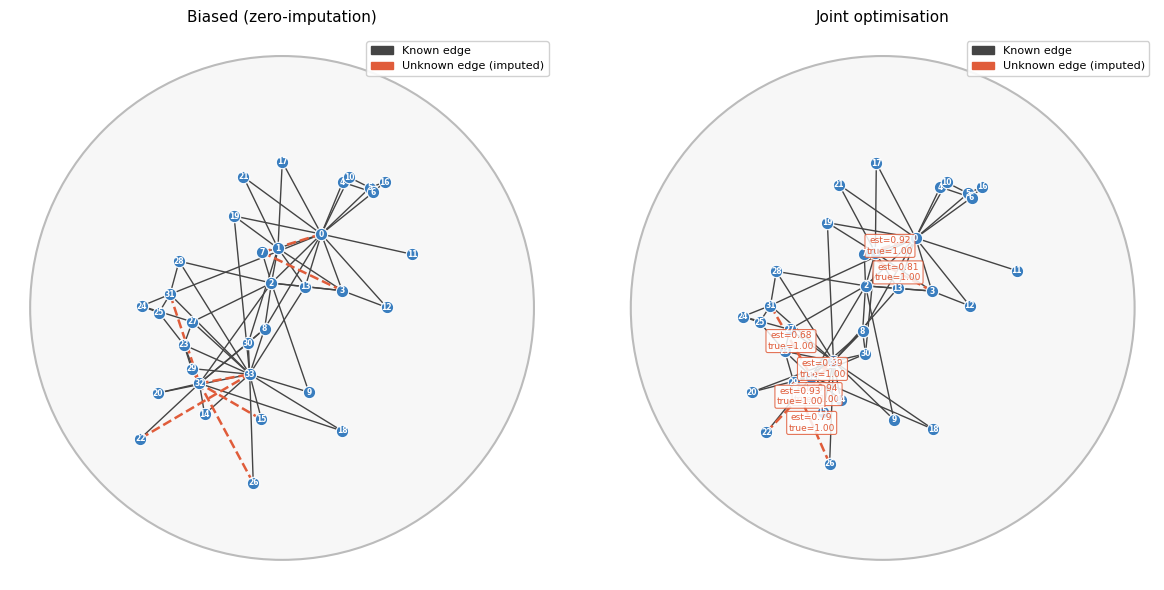

In [11]:
true_weights = {(min(m,n), max(m,n)): 1.0 for m,n in unknown_edges}

fig, axes = plt.subplots(1, 2, figsize=(13, 6))

plot_poincare_graph(
    G, biased.embeddings(), unknown_edges,
    a_omega_estimated=np.zeros(len(unknown_edges)),
    show_weights=False,
    title='Biased (zero-imputation)',
    ax=axes[0],
)
plot_poincare_graph(
    G, joint.embeddings(), unknown_edges,
    a_omega_estimated=joint.imputed_weights,
    true_weights=true_weights,
    title='Joint optimisation',
    ax=axes[1],
)
fig.show()

## Loss curves

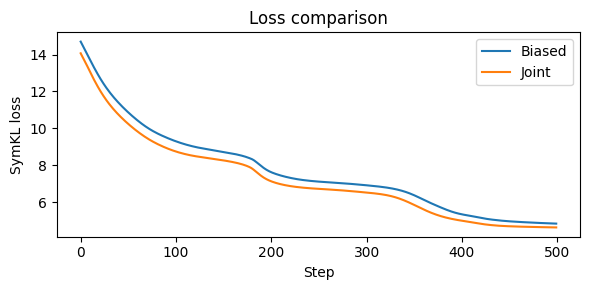

In [12]:
fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(biased.loss_history, label='Biased')
ax.plot(joint.loss_history,  label='Joint')
ax.set_xlabel('Step'); ax.set_ylabel('SymKL loss')
ax.legend(); ax.set_title('Loss comparison')
fig.tight_layout()
fig.savefig('unknown_edges_loss.png', dpi=150, bbox_inches='tight')

## Gradient of the loss w.r.t. unknown entries

For reference, the analytical gradient of the SymKL loss w.r.t. an unknown edge weight $a_{mn}$ is:

$$\frac{\partial \mathcal{L}}{\partial a_{mn}} = H_{mn} + H_{nm} - H_{mm} - H_{nn}$$

where $H = Q G^\top Q$ and $G_{ij} = -\hat{A}_{ij}/Q_{ij} + \log(Q_{ij}/\hat{A}_{ij}) + 1$.

This is computed automatically by PyTorch autograd through the `forest_matrix` and `soft_decoder` calls.